In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sn
from sklearn import preprocessing
import json

In [2]:
dataframe = pd.read_csv("car_price_dataset.csv")
dataframe.head()

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


#### Check data consistency and null values

##### Check null values

In [3]:
dataframe.isnull().values.any()

False

In [4]:
(dataframe == ' ').values.any()

False

In [5]:
(dataframe == '').values.any()

False

In [6]:
(dataframe == '\t').values.any()

False

In [7]:
(dataframe == '  ').values.any()

False

##### Check dtypes of columns

In [8]:
dataframe.dtypes

Brand            object
Model            object
Year              int64
Engine_Size     float64
Fuel_Type        object
Transmission     object
Mileage           int64
Doors             int64
Owner_Count       int64
Price             int64
dtype: object

##### Check for negative values

In [9]:
non_obj_mask = (dataframe.dtypes != "object").values
(dataframe[dataframe.columns[non_obj_mask]] < 0).values.any()

False

##### Check for groups

In [10]:
obj_mask = (dataframe.dtypes == "object").values
for col in dataframe.columns[obj_mask]:
    print(col)
    print(dataframe[col].unique())
    print()

Brand
['Kia' 'Chevrolet' 'Mercedes' 'Audi' 'Volkswagen' 'Toyota' 'Honda' 'BMW'
 'Hyundai' 'Ford']

Model
['Rio' 'Malibu' 'GLA' 'Q5' 'Golf' 'Camry' 'Civic' 'Sportage' 'RAV4'
 '5 Series' 'CR-V' 'Elantra' 'Tiguan' 'Equinox' 'Explorer' 'A3' '3 Series'
 'Tucson' 'Passat' 'Impala' 'Corolla' 'Optima' 'Fiesta' 'A4' 'Focus'
 'E-Class' 'Sonata' 'C-Class' 'X5' 'Accord']

Fuel_Type
['Diesel' 'Hybrid' 'Electric' 'Petrol']

Transmission
['Manual' 'Automatic' 'Semi-Automatic']



### Data Analysis

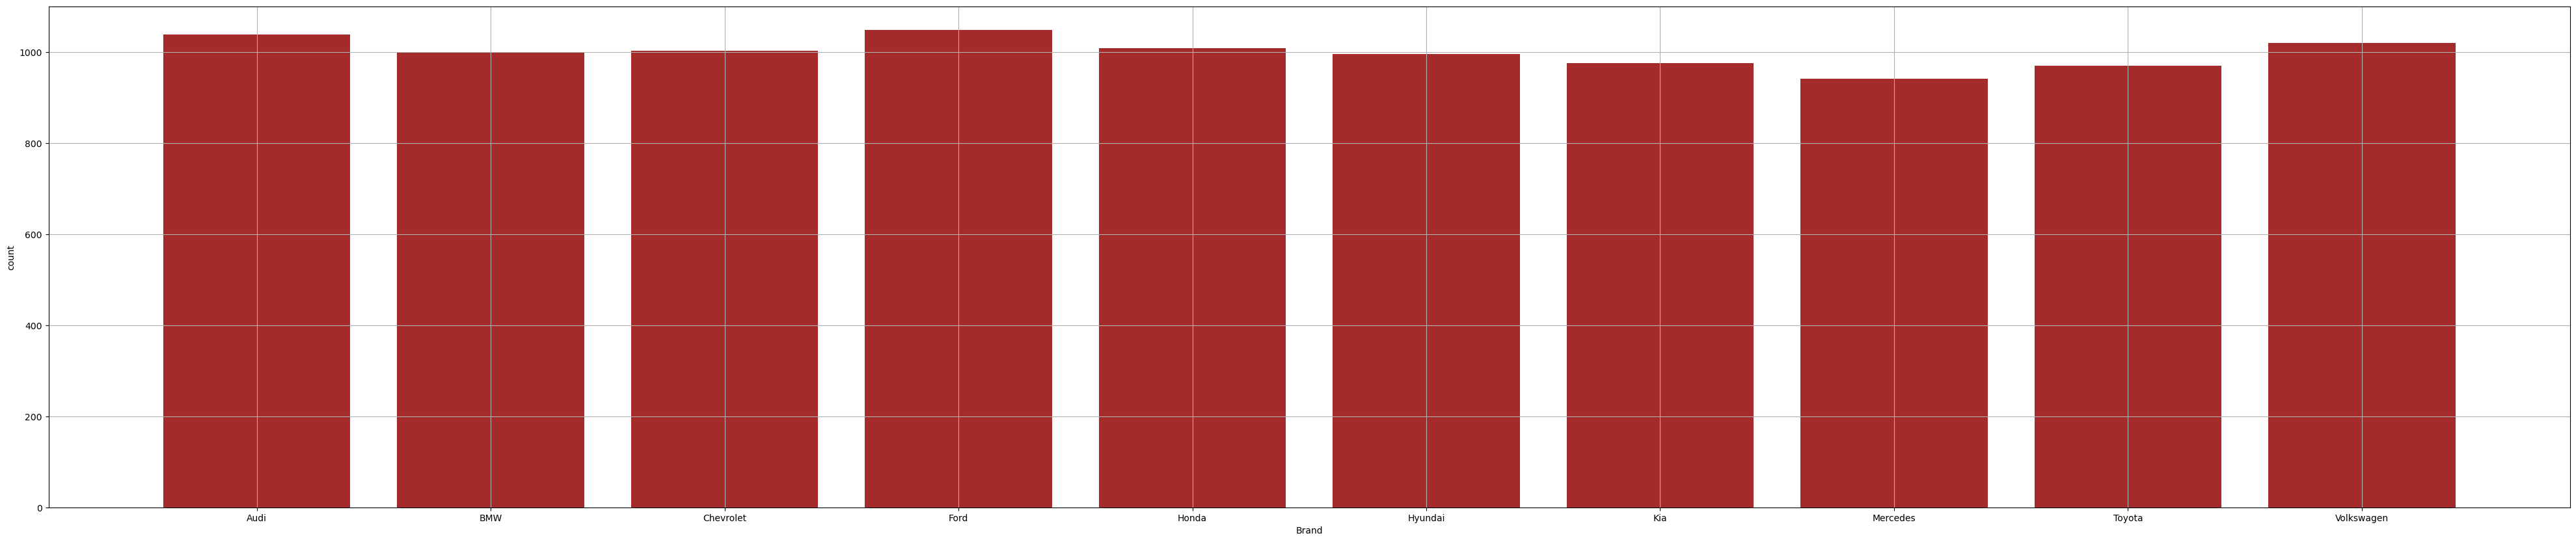

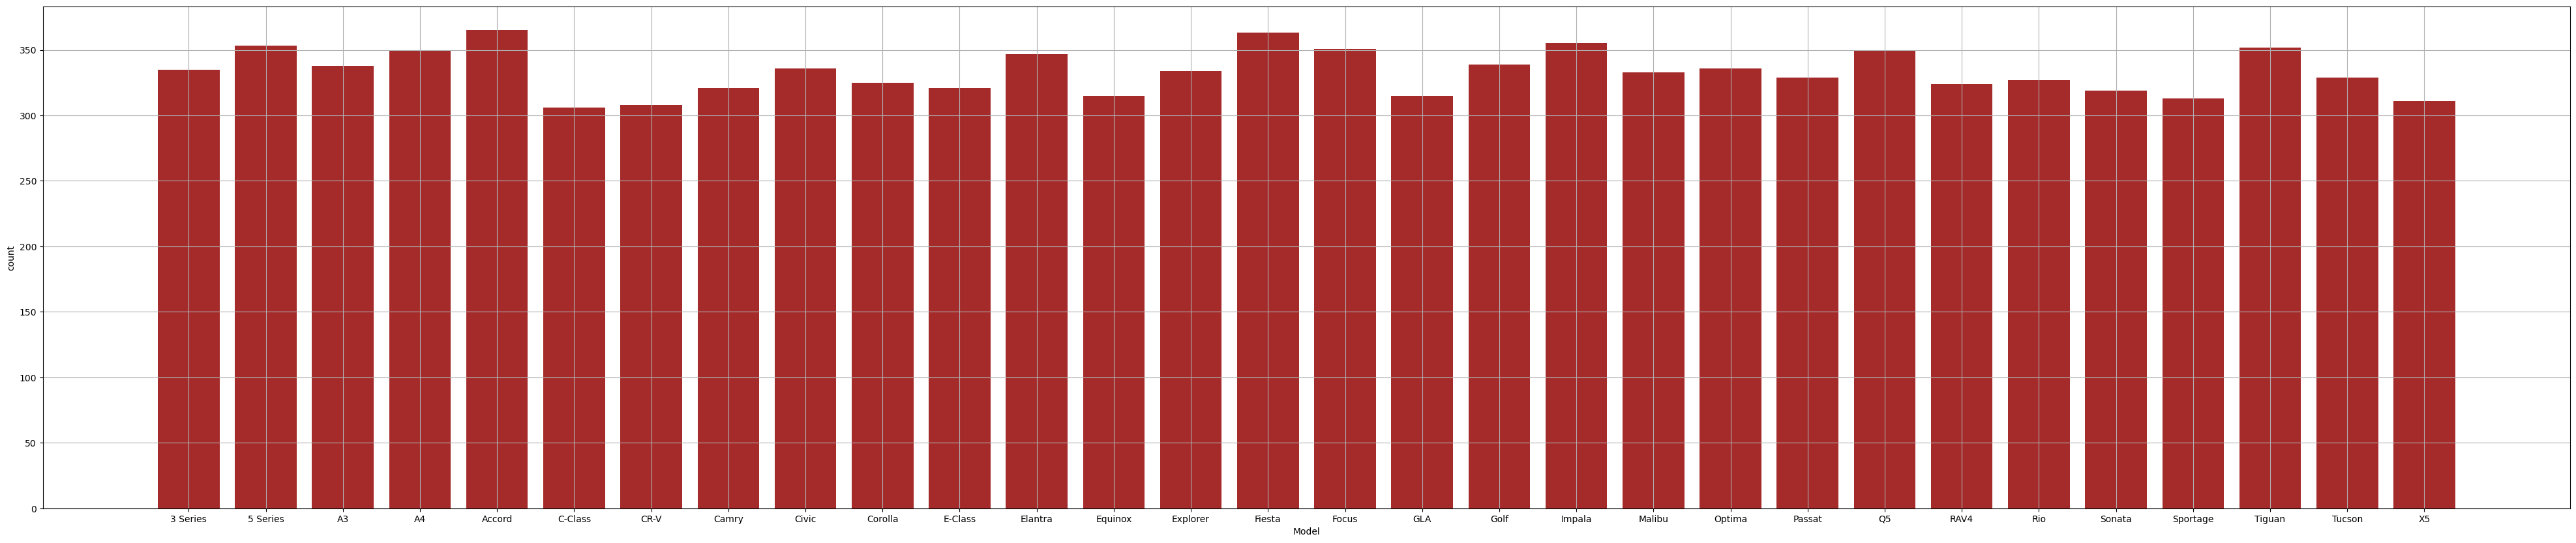

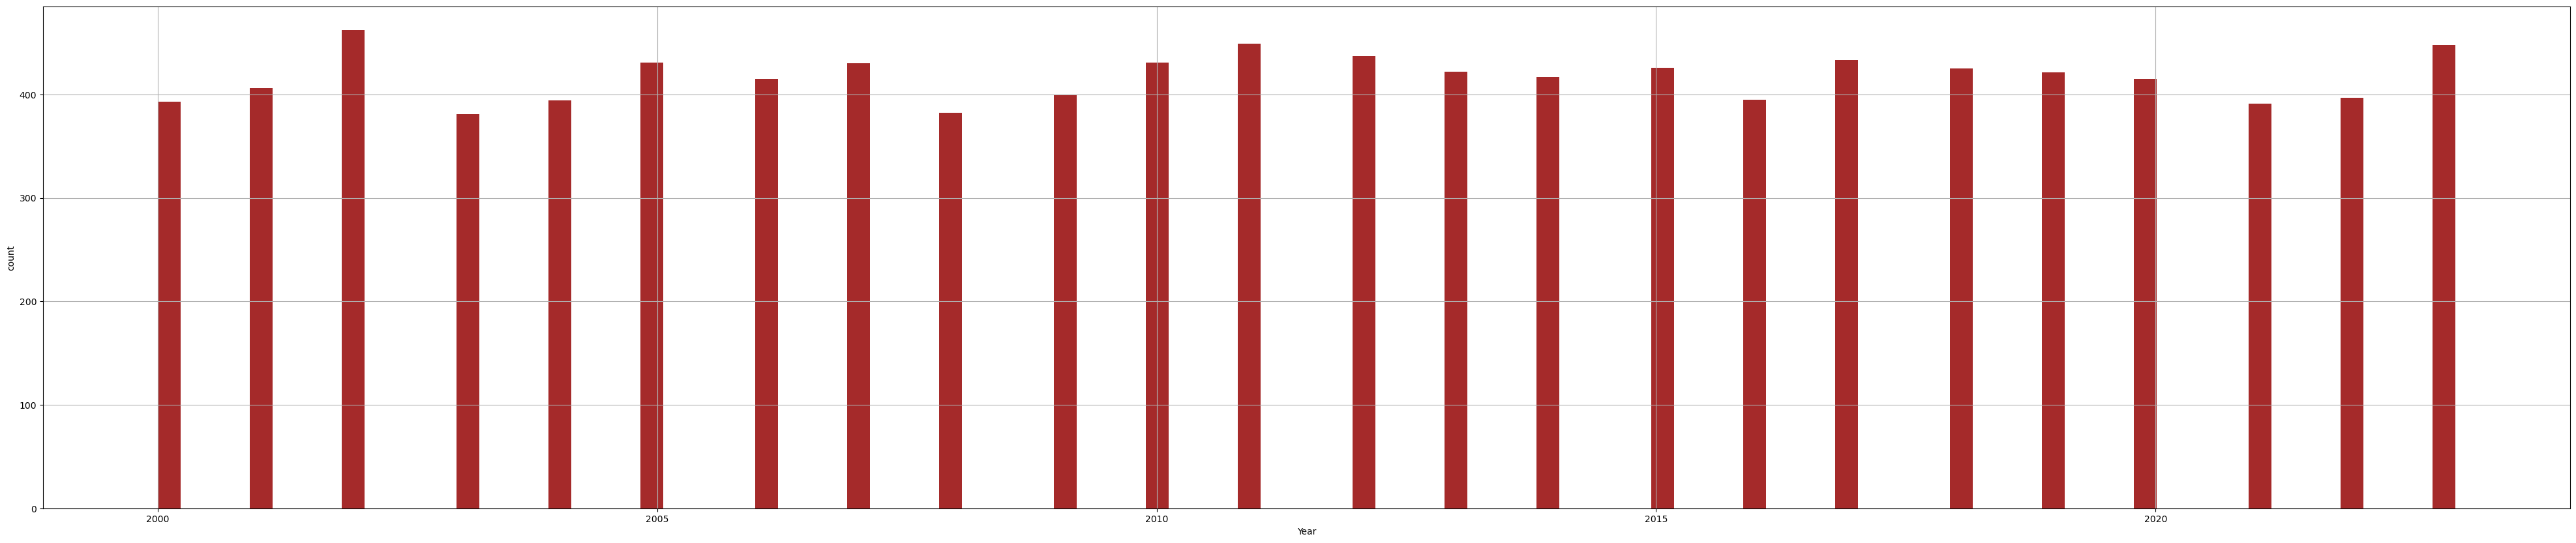

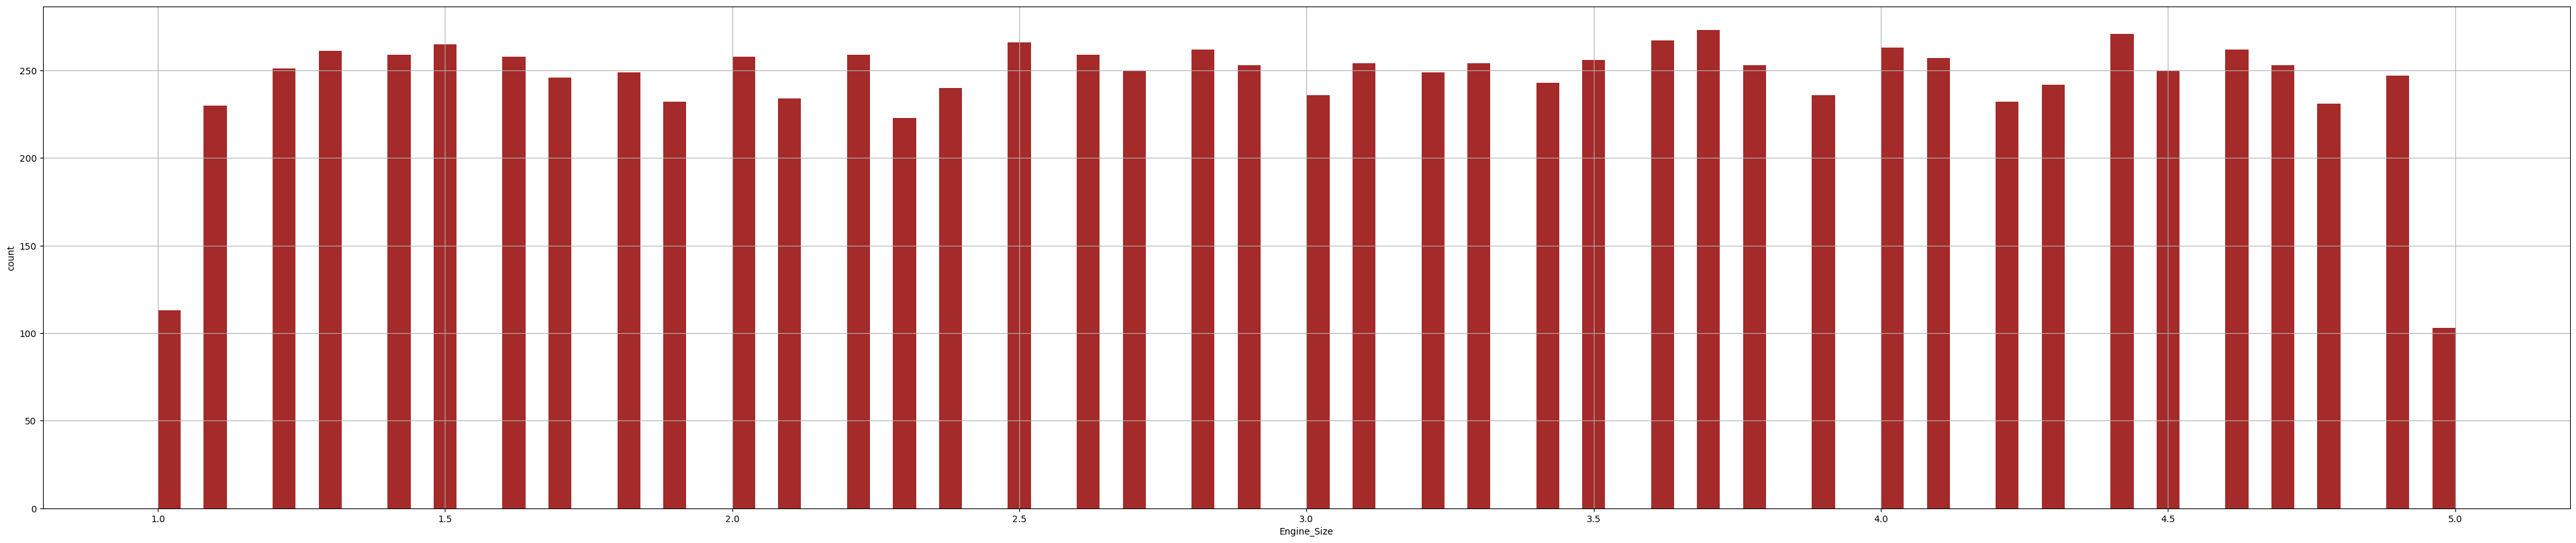

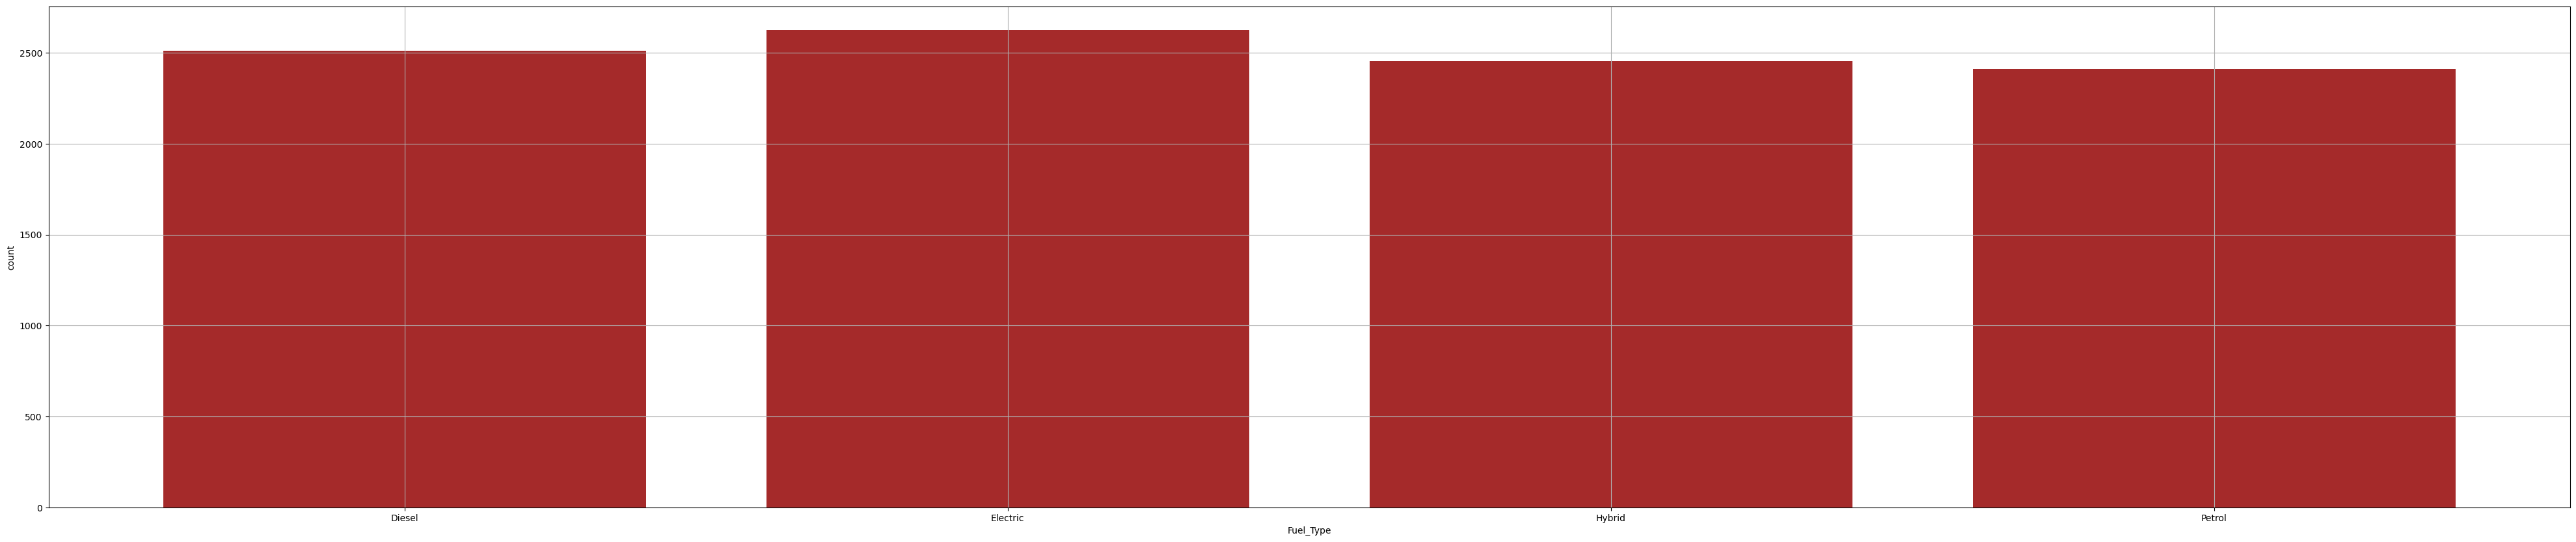

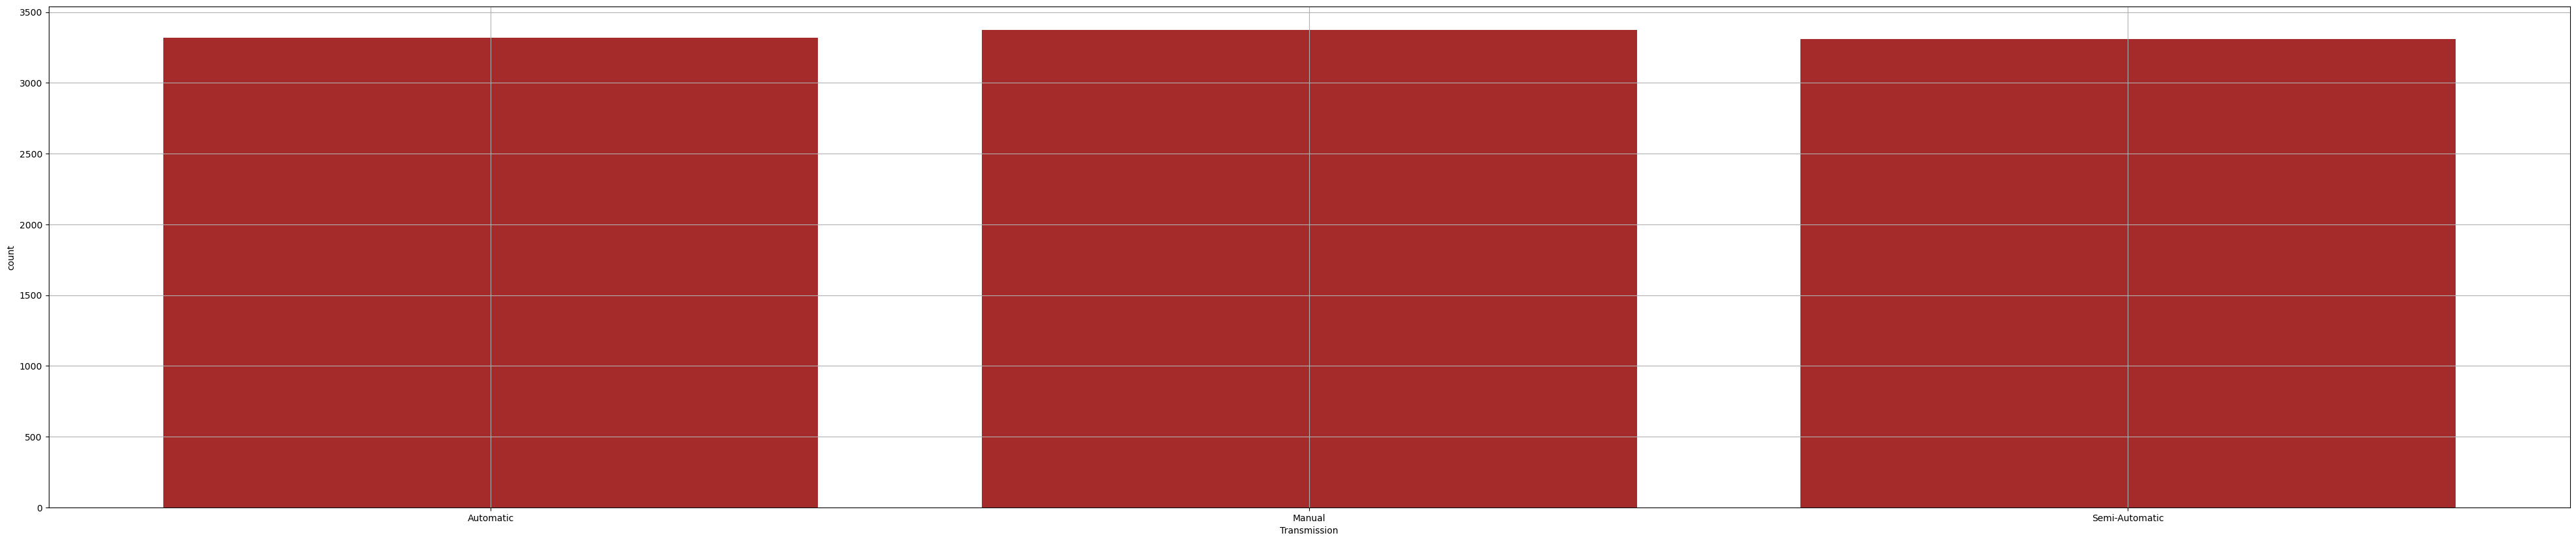

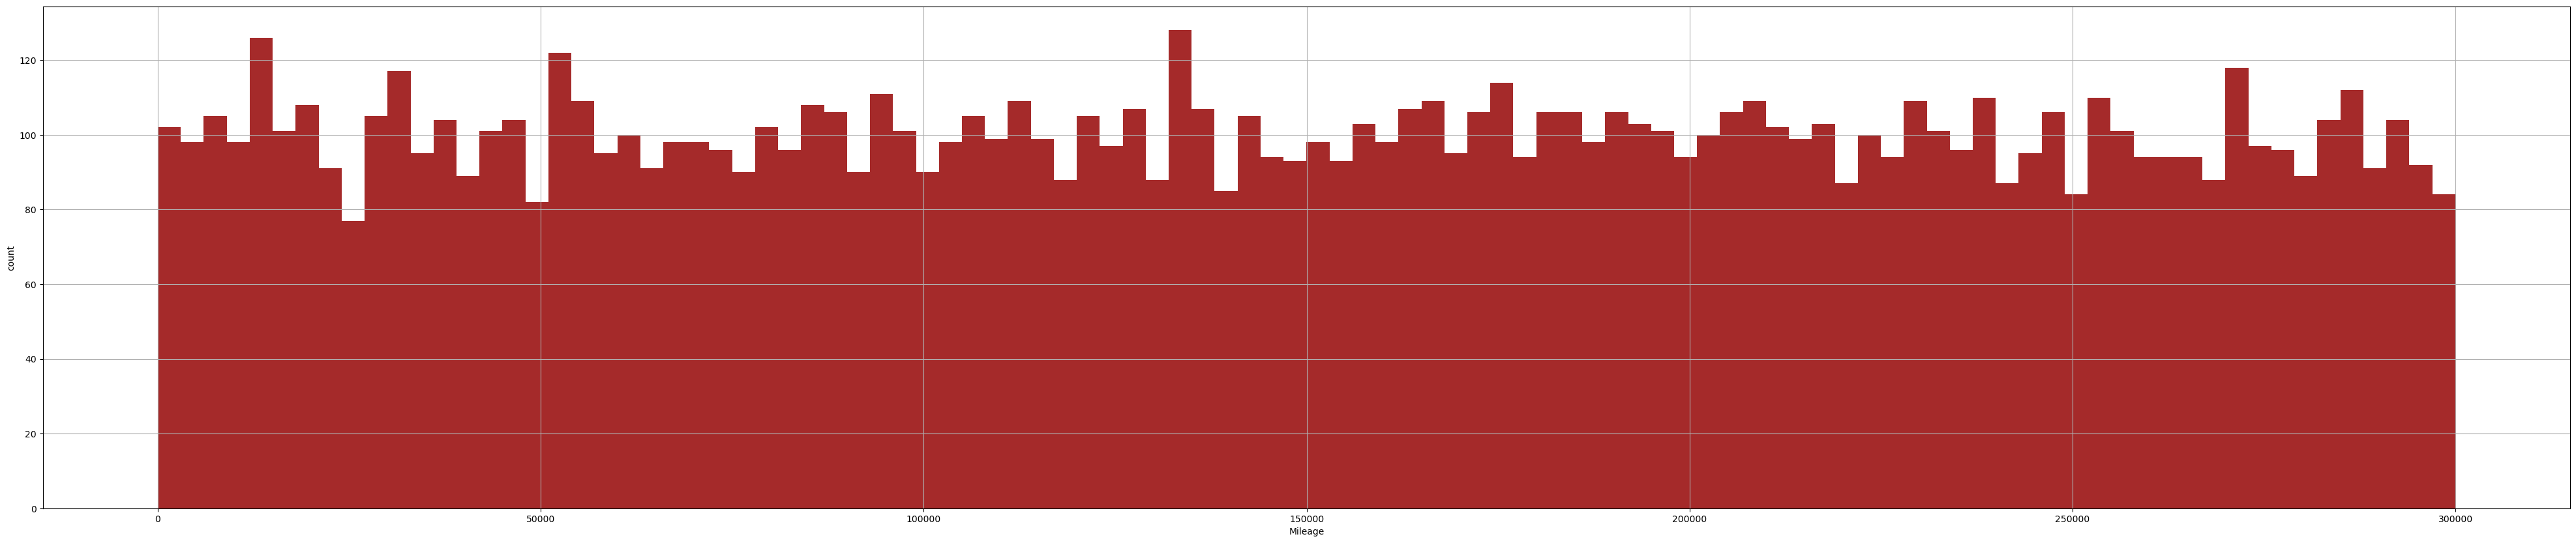

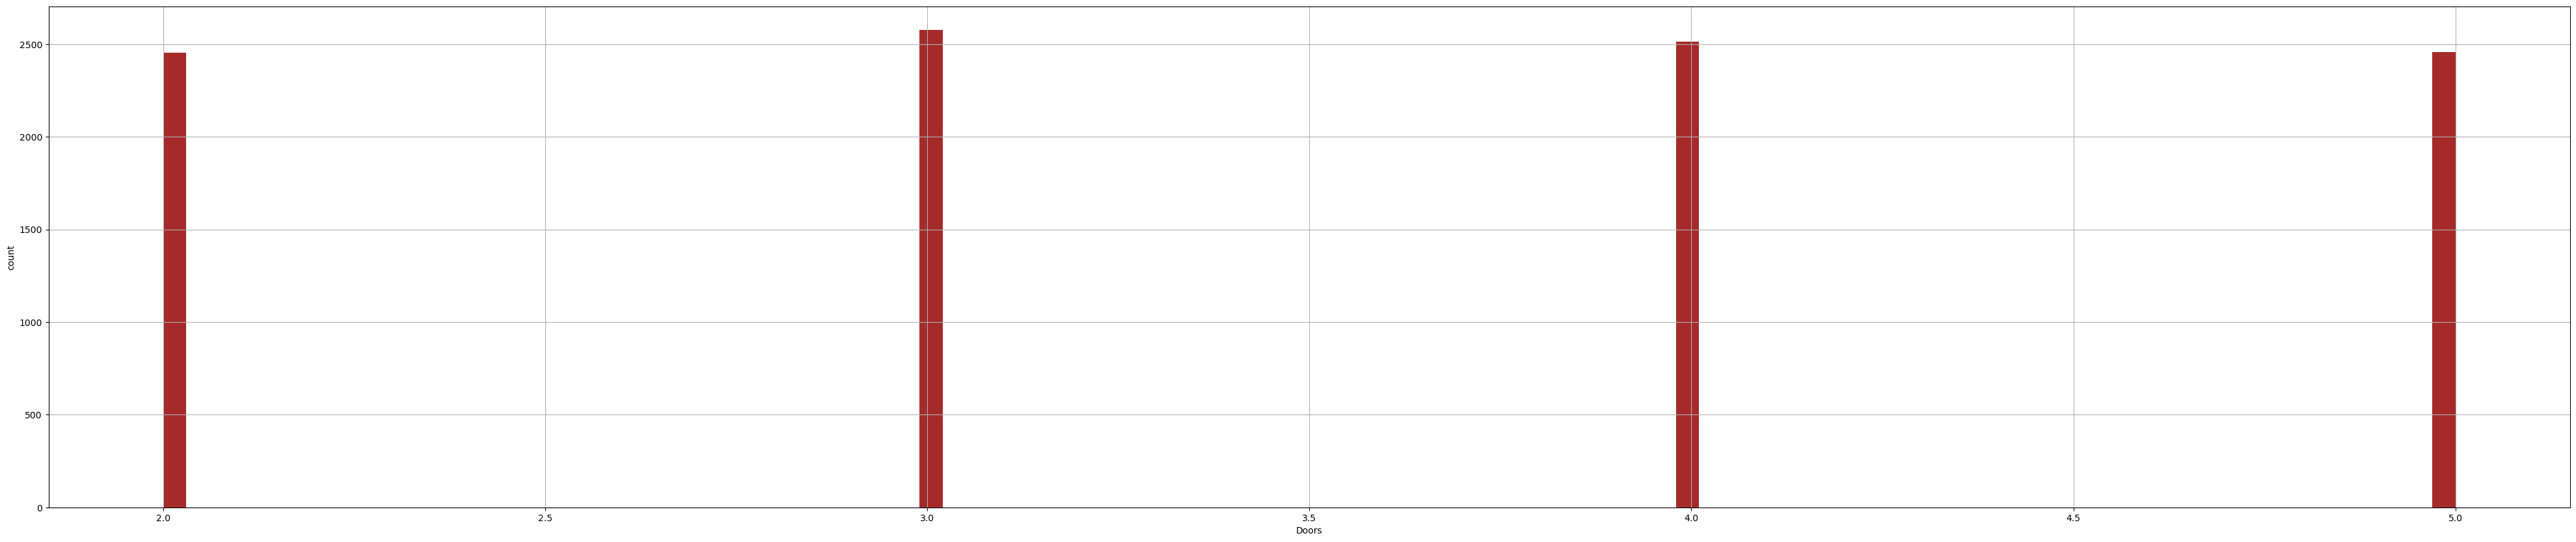

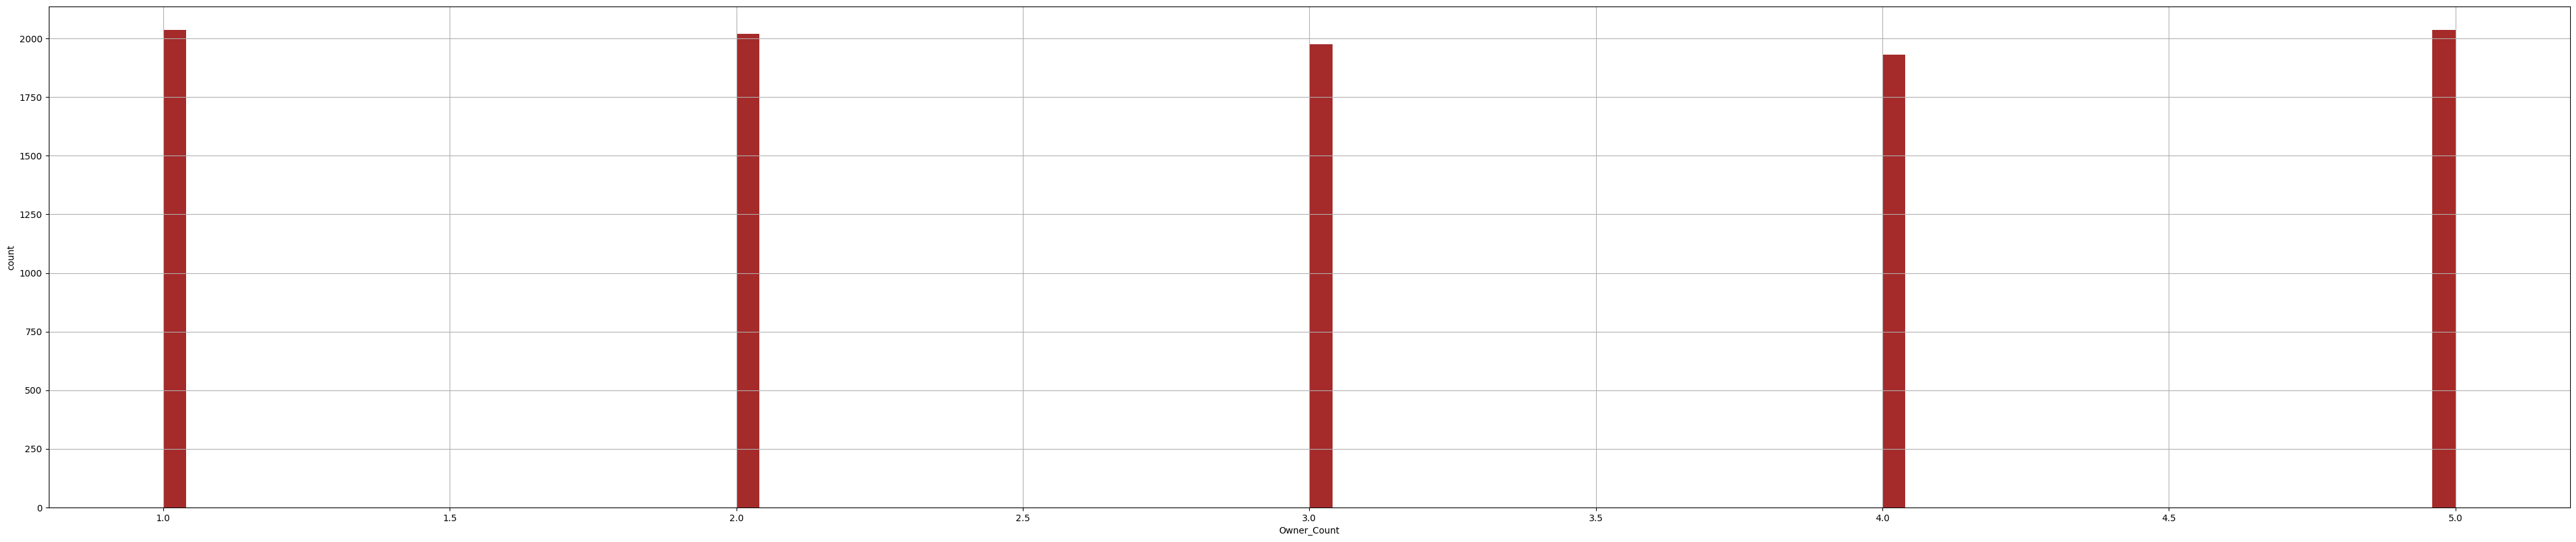

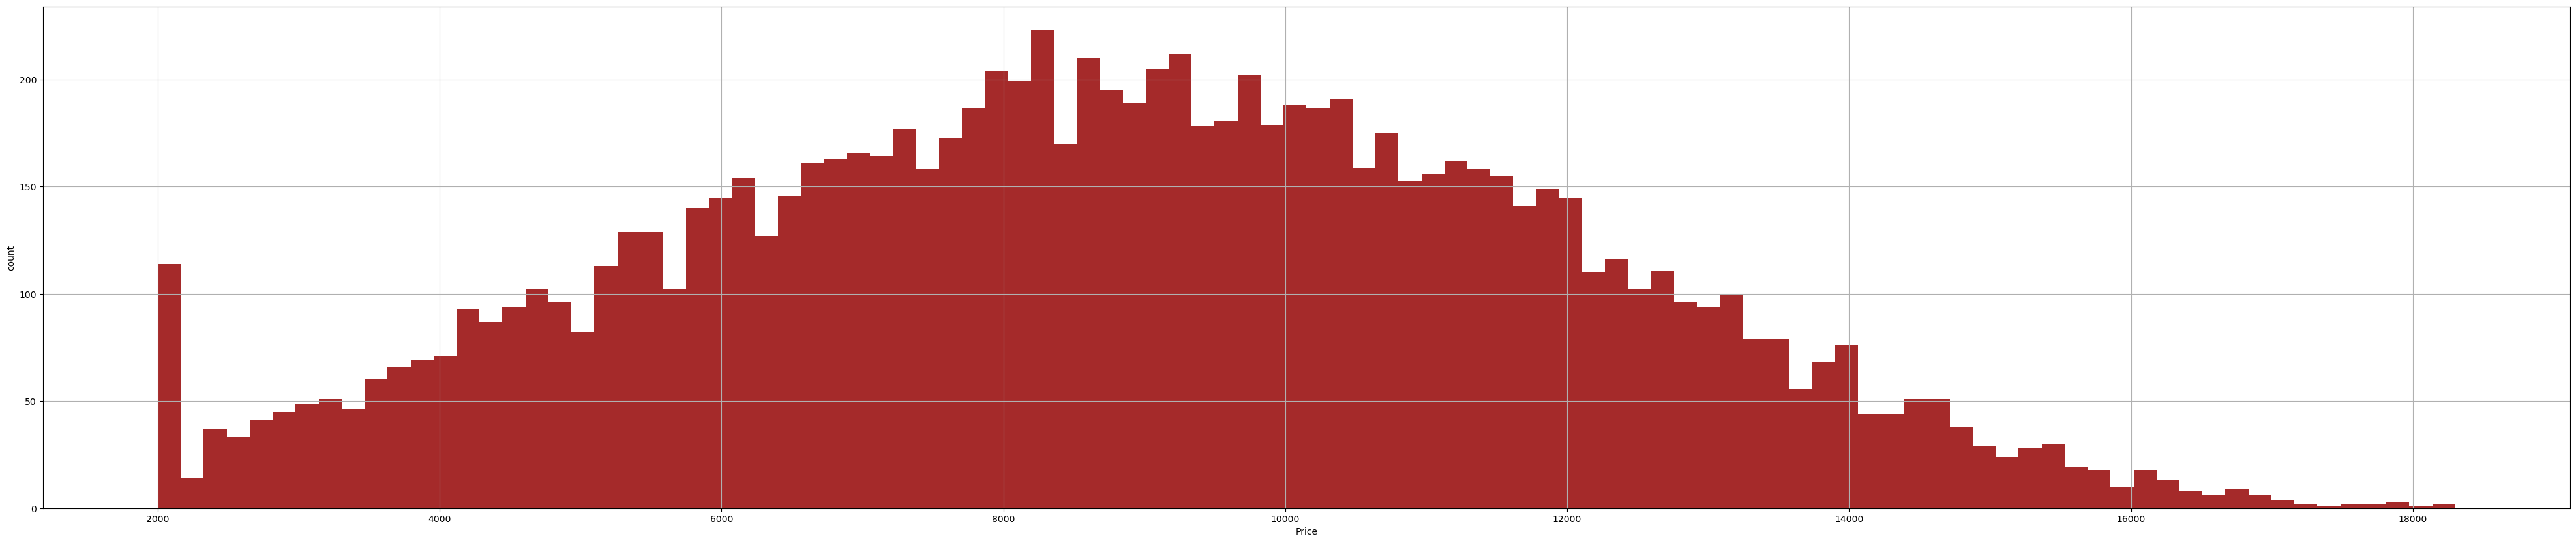

In [11]:
for col in dataframe.columns:
    plt.figure(figsize=(50, 10))
    plt.grid()
    if dataframe[col].dtype == "object":
        group_by_res = dataframe.groupby(col)[col].count()
        keys = group_by_res.keys()
        values = group_by_res.values
        plt.bar(keys, values, color="brown")
    else:
        values = dataframe[col].values
        plt.hist(values, bins=100, color="brown")
    plt.xlabel(col)
    plt.ylabel('count')
    plt.savefig(f'EDA/{col}.png')
    plt.show()

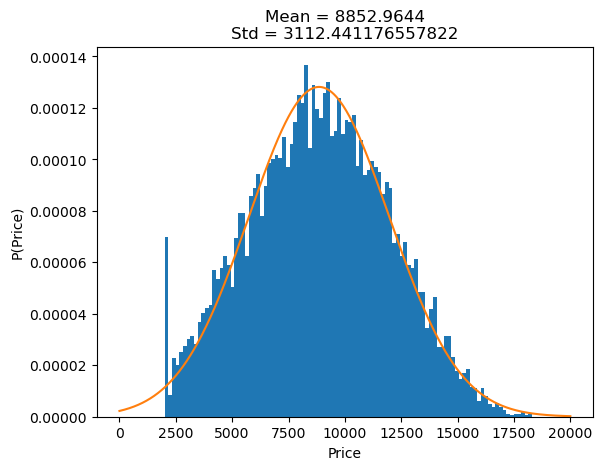

In [12]:
price_values = dataframe['Price'].values
price_mean = np.mean(price_values)
price_var = np.var(price_values)

gaussian = (1 / (np.sqrt(2 * np.pi * price_var))) * (np.exp(-((np.arange(0, 20000) - price_mean) ** 2) / (2 * price_var)))

plt.title(f"Mean = {price_mean}\nStd = {np.sqrt(price_var)}")
plt.xlabel("Price")
plt.ylabel("P(Price)")
plt.hist(price_values, bins=100, density=True)
plt.plot(gaussian)
plt.savefig("EDA/price_gaussian.png")

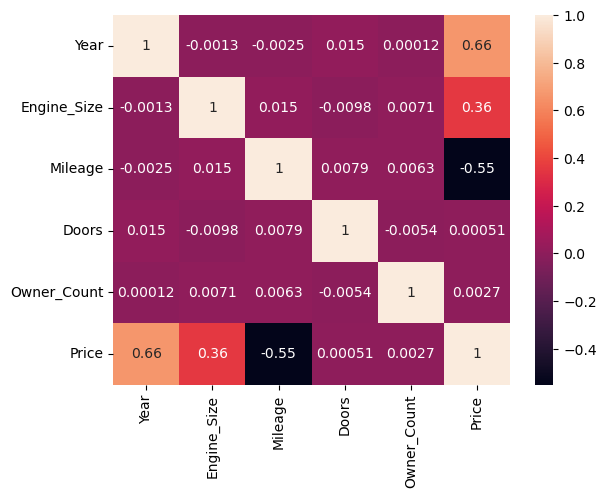

In [13]:
mask = (dataframe.dtypes != "object").values
correleation = dataframe[dataframe.columns[mask]].corr()
heatmap = sn.heatmap(correleation, annot=True)
fig = heatmap.get_figure()
fig.savefig("EDA/Heatmap.png")

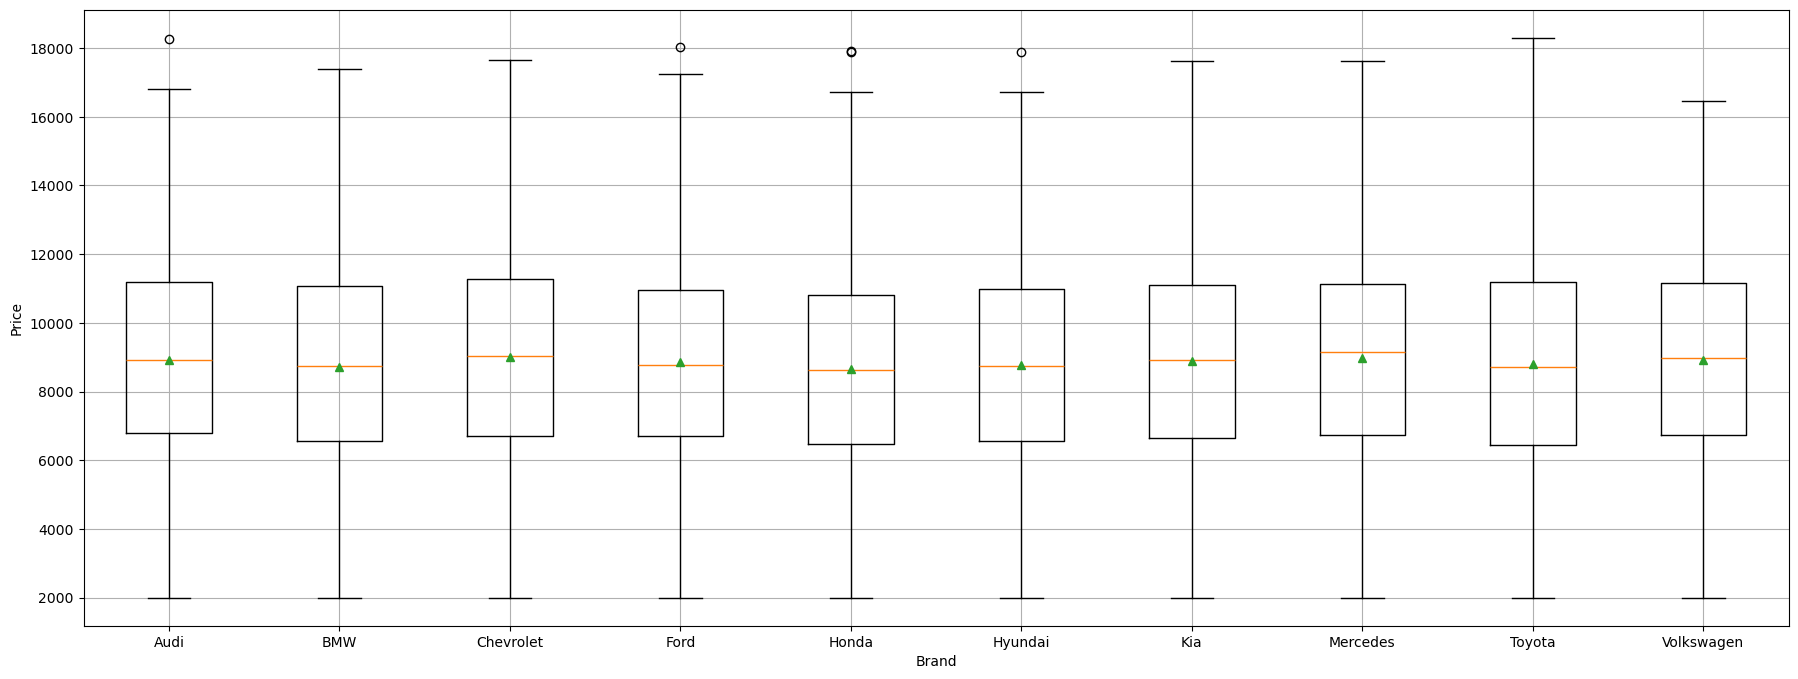

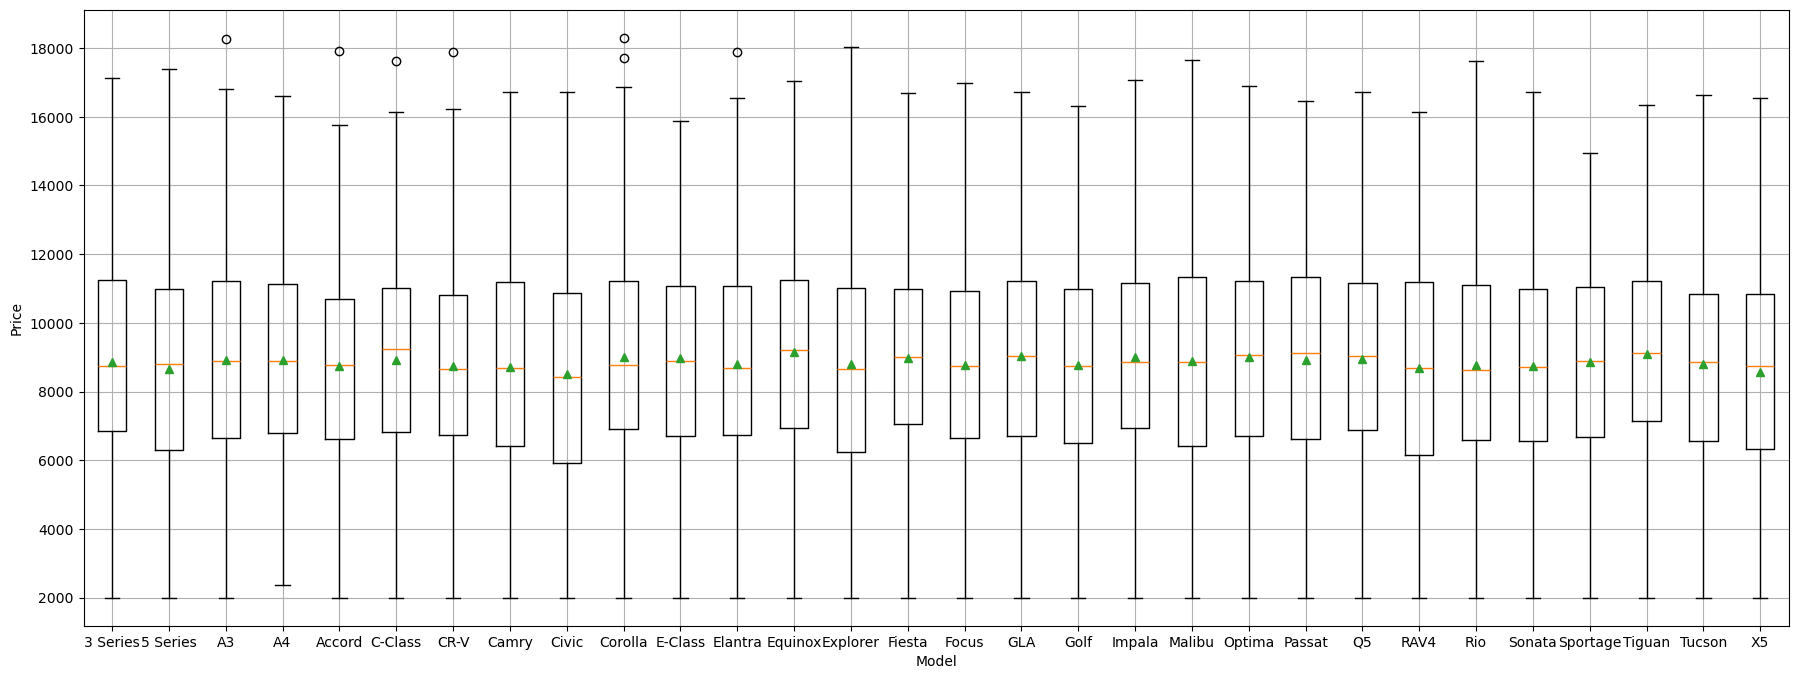

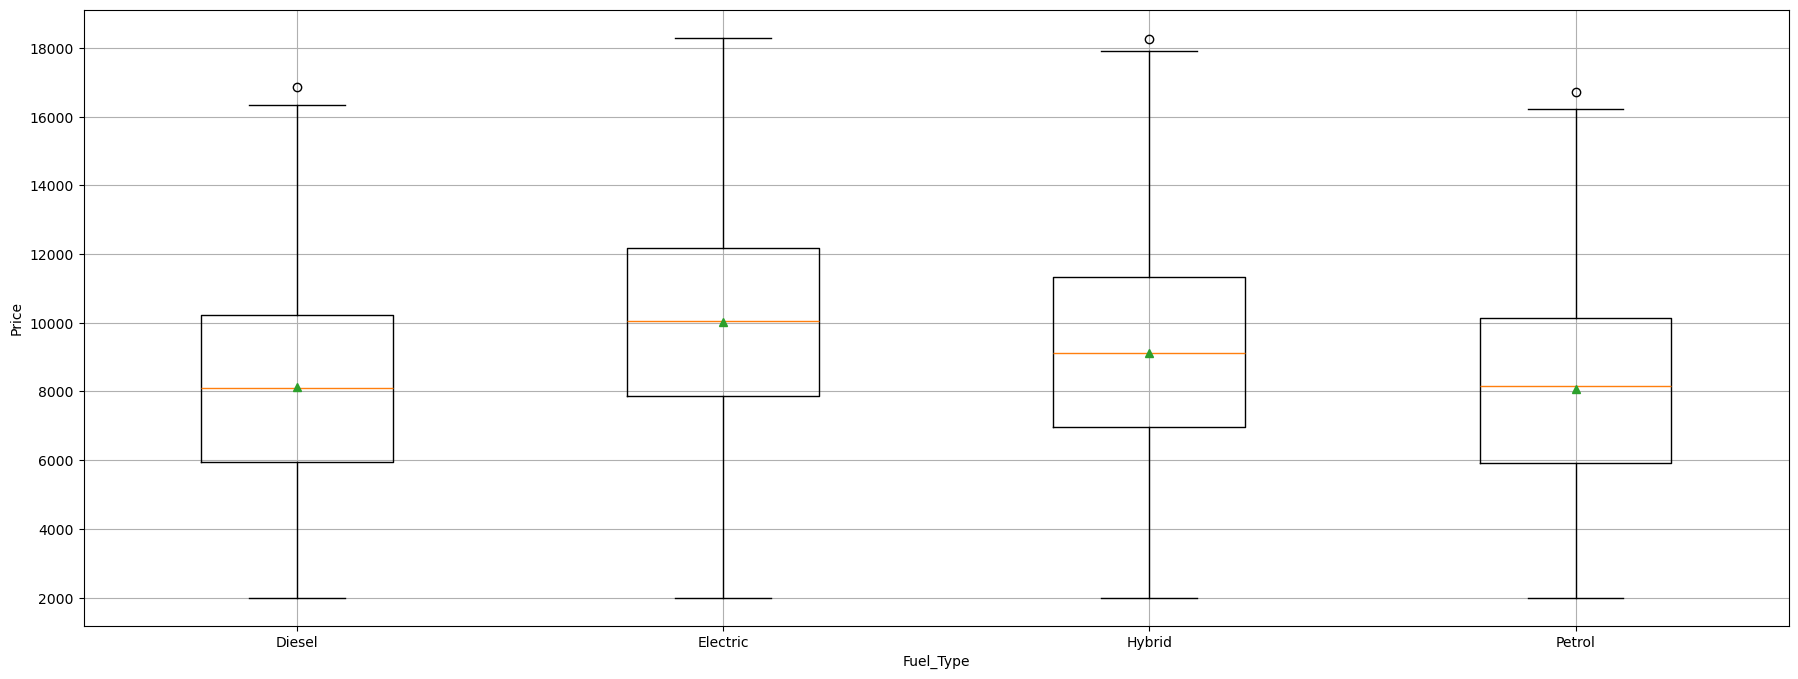

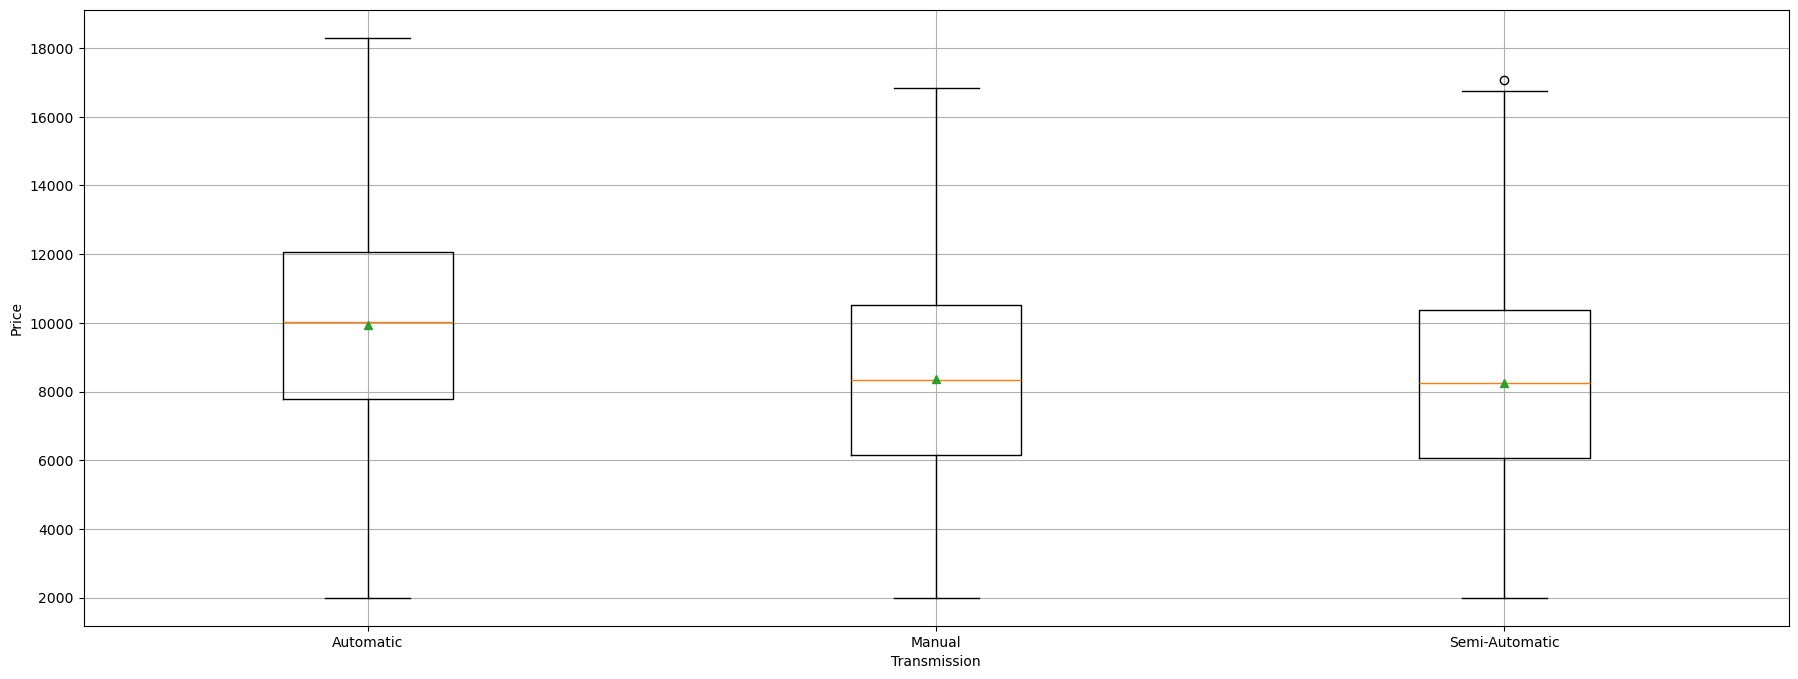

In [14]:
for col in dataframe.columns:
    if dataframe[col].dtype == "object":
        vals = dataframe[[col, "Price"]].values
        sorted_with_col = vals[vals[:, 0].argsort(), :]
        col_categories = np.expand_dims(np.unique(sorted_with_col[:, 0]), axis=-1)
        price_values = np.expand_dims(sorted_with_col[:, 0], axis=0)
        lists = [sorted_with_col[:, 1][a] for a in list(price_values == col_categories)]
        plt.figure(figsize=(22, 8))
        _ = plt.boxplot(lists, showmeans=True, tick_labels=col_categories.squeeze())
        plt.xlabel(col)
        plt.grid()
        plt.ylabel("Price")
        plt.savefig(f"EDA/{col}_Box.png")
        plt.show()

In [15]:
classes_lst = []
def convert_to_label_encoding(col):
    label_encoder = preprocessing.LabelEncoder()
    encoded = label_encoder.fit_transform(col)
    classes_lst.append(label_encoder.classes_.tolist())
    return encoded

dataframe_cpy = dataframe.copy(deep=True)
mask = (dataframe_cpy.dtypes == "object").values
str_cols = dataframe_cpy.columns[mask]
dataframe_cpy[str_cols] = dataframe_cpy[str_cols].apply(convert_to_label_encoding)

In [16]:
dataframe_cpy

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,6,24,2020,4.2,0,1,289944,3,5,8501
1,2,19,2012,2.0,2,0,5356,2,3,12092
2,7,16,2020,4.2,0,0,231440,4,2,11171
3,0,22,2023,2.0,1,1,160971,2,1,11780
4,9,17,2003,2.6,2,2,286618,3,3,2867
...,...,...,...,...,...,...,...,...,...,...
9995,6,20,2004,3.7,0,2,5794,2,4,8884
9996,2,18,2002,1.4,1,0,168000,2,1,6240
9997,1,0,2010,3.0,3,0,86664,5,1,9866
9998,3,13,2002,1.4,2,0,225772,4,1,4084


In [17]:
dataset = dataframe_cpy.to_numpy()
x = dataset[:, :-1]
y = dataset[:, -1]

print(x.shape)
print(y.shape)

(10000, 9)
(10000,)


In [18]:
with open('x_dataset.npy', 'wb') as f:
    np.save(f, x)

with open('y_dataset.npy', 'wb') as f:
    np.save(f, y)

In [19]:
classes_dict = dict(zip(str_cols, classes_lst))
with open("mappings.json", "w") as file:
    json.dump(classes_dict, file)